In [5]:
# 导入所需库
import pandas as pd
import matplotlib.pyplot as plt
import os

# 设置中文字体，避免可视化时中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

一、数据探查

1.1 数据合并：将指定文件夹下的9个CSV文件合并成1个

In [9]:
# 定义文件路径
file_path = r'C:\Users\86151\Desktop\jobs'
all_df = []

# 遍历文件夹下的所有CSV文件
for filename in os.listdir(file_path):
    if filename.endswith('.csv'):
        # 读取单个CSV文件
        temp_df = pd.read_csv(os.path.join(file_path, filename), encoding='gbk')
        all_df.append(temp_df)
# 合并所有数据并保存为新文件
all_jobs_df = pd.concat(all_df, ignore_index=True)
all_jobs_df.to_csv('all_jobs.csv', index=False, encoding='gbk')

1.2 读取汇总后的CSV文件

In [12]:
#  读取汇总后的CSV文件
all_jobs_df = pd.read_csv('all_jobs.csv', encoding='gbk')
all_jobs_df

,company_name,uri,salary,site,year,edu,job_name,city,job_type
0,中国电信云,https://www.zhipin.com/job_detail/11266fc18dc1...,20-40K·17薪,北京 海淀区 西山,经验不限,本科,Python,beijing,python
1,奇虎360,https://www.zhipin.com/job_detail/2a3103941dc2...,10-20K·15薪,北京 朝阳区 酒仙桥,3-5年,大专,python数据分析师,beijing,python
2,VIPKID,https://www.zhipin.com/job_detail/2dd7f2760947...,20-40K·14薪,北京 朝阳区 十里堡,5-10年,本科,Python,beijing,python
3,天阳科技,https://www.zhipin.com/job_detail/a0c8485a448b...,12-24K,北京 石景山区 八宝山,1-3年,本科,python工程师,beijing,python
4,武汉佰钧成,https://www.zhipin.com/job_detail/d6627bf7c1e2...,12-17K,北京 朝阳区 三元桥,3-5年,大专,python开发,beijing,python
...,...,...,...,...,...,...,...,...,...
9820,公众智能,https://www.zhipin.com/job_detail/7b9c08dbce81...,8-10K,西安,3-5年,本科,产品经理,xian,产品经理
9821,微感,https://www.zhipin.com/job_detail/c7e99005528f...,8-10K,西安 雁塔区 紫薇田园都市,3-5年,大专,产品经理,xian,产品经理
9822,巴斯光年,https://www.zhipin.com/job_detail/1045fe64f248...,10-20K,西安 雁塔区 大雁塔,3-5年,本科,产品经理,xian,产品经理
9823,西大华特科技,https://www.zhipin.com/job_detail/e3c21cc748e7...,5-8K,西安 雁塔区 唐延路,1-3年,硕士,产品经理（农药）,xian,产品经理


1.3. 读取指定列并命名为job数据框

In [15]:
# 读取指定列并命名为job数据框
columns = ['company_name', 'salary', 'site', 'year', 'edu', 'job_name', 'job_type']
job = all_jobs_df[columns].copy()

1.4 查看DataFrame全体数据摘要信息（info）

In [18]:
#查看DataFrame全体数据摘要信息
print("数据摘要信息：")
print(job.info())
print("\n数据前5行：")
print(job.head())

数据摘要信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9825 entries, 0 to 9824
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  9825 non-null   object
 1   salary        9825 non-null   object
 2   site          9825 non-null   object
 3   year          9825 non-null   object
 4   edu           9825 non-null   object
 5   job_name      9825 non-null   object
 6   job_type      9825 non-null   object
dtypes: object(7)
memory usage: 537.4+ KB
None

数据前5行：
  company_name      salary         site   year edu     job_name job_type
0        中国电信云  20-40K·17薪    北京 海淀区 西山   经验不限  本科       Python   python
1        奇虎360  10-20K·15薪   北京 朝阳区 酒仙桥   3-5年  大专  python数据分析师   python
2       VIPKID  20-40K·14薪   北京 朝阳区 十里堡  5-10年  本科       Python   python
3         天阳科技      12-24K  北京 石景山区 八宝山   1-3年  本科    python工程师   python
4        武汉佰钧成      12-17K   北京 朝阳区 三元桥   3-5年  大专     python开发   python


二、数据预处理

2.1 查看岗位类型

In [22]:
# 查看岗位类型
print("\n岗位类型分布：")
print(job['job_type'].value_counts())


岗位类型分布：
job_type
java      2688
产品经理      2688
数据分析      2431
python    2018
Name: count, dtype: int64


2.2 使用query函数筛选与数据分析相关的岗位类型

In [25]:
# 使用query函数筛选与数据分析相关的岗位类型
job = job.query("job_type.str.contains('数据分析', na=False)", engine='python')
job

,company_name,salary,site,year,edu,job_name,job_type
577,京东数字科技,20-40K,北京 大兴区 次渠,3-5年,本科,数据分析,数据分析
578,瑞幸咖啡,15-30K,北京 海淀区 知春路,1-3年,本科,数据分析师,数据分析
579,VIPKID,30-60K·14薪,北京 朝阳区 十里堡,5-10年,本科,数据分析专家,数据分析
580,京东集团,7-14K,北京,3-5年,本科,数据分析主管,数据分析
581,BOSS直聘,18-25K·16薪,北京 朝阳区 太阳宫,1-3年,博士,数据分析,数据分析
...,...,...,...,...,...,...,...
9520,梦之童,8-9K,西安 新城区 解放路,1年以内,大专,医学总监,数据分析
9521,平安普惠,5-10K,西安 雁塔区 唐延路,1年以内,大专,风控,数据分析
9522,耳垂网络科技,15-18K,西安 雁塔区 小寨,1-3年,本科,算法研究员,数据分析
9523,森弗集团,3-6K,西安,经验不限,本科,IT技术支持,数据分析


2.3 筛选出python和数据分析的岗位

In [28]:
# 筛选出包含python和数据分析的岗位（job_name中包含这两个关键词）
job = job.query("job_name.str.contains('python|数据分析', na=False, case=False)", engine='python')
job

,company_name,salary,site,year,edu,job_name,job_type
577,京东数字科技,20-40K,北京 大兴区 次渠,3-5年,本科,数据分析,数据分析
578,瑞幸咖啡,15-30K,北京 海淀区 知春路,1-3年,本科,数据分析师,数据分析
579,VIPKID,30-60K·14薪,北京 朝阳区 十里堡,5-10年,本科,数据分析专家,数据分析
580,京东集团,7-14K,北京,3-5年,本科,数据分析主管,数据分析
581,BOSS直聘,18-25K·16薪,北京 朝阳区 太阳宫,1-3年,博士,数据分析,数据分析
...,...,...,...,...,...,...,...
9393,直信立兴,2-4K,西安 未央区 未央路,1年以内,大专,数据分析师,数据分析
9394,思普瑞数码,8-9K,西安 雁塔区 沣惠南路,1-3年,本科,数据分析师,数据分析
9395,中邮速递易,6-8K,西安 雁塔区 唐延路,1-3年,本科,数据分析师,数据分析
9396,斯维智能,5-9K,西安 雁塔区 高新路,应届生,本科,数据分析师,数据分析


2.4 统一job_name字段的大小写（筛选数据的时候不会因为大小写问题出错）
job.job_name = job.job_name.str.title()
job

In [31]:
#创建副本
job_copy=job.copy()

In [33]:
#  统一job_name字段的大小写（Title格式：首字母大写，其余小写）
job_copy.job_name = job.job_name.str.title()
job

,company_name,salary,site,year,edu,job_name,job_type
577,京东数字科技,20-40K,北京 大兴区 次渠,3-5年,本科,数据分析,数据分析
578,瑞幸咖啡,15-30K,北京 海淀区 知春路,1-3年,本科,数据分析师,数据分析
579,VIPKID,30-60K·14薪,北京 朝阳区 十里堡,5-10年,本科,数据分析专家,数据分析
580,京东集团,7-14K,北京,3-5年,本科,数据分析主管,数据分析
581,BOSS直聘,18-25K·16薪,北京 朝阳区 太阳宫,1-3年,博士,数据分析,数据分析
...,...,...,...,...,...,...,...
9393,直信立兴,2-4K,西安 未央区 未央路,1年以内,大专,数据分析师,数据分析
9394,思普瑞数码,8-9K,西安 雁塔区 沣惠南路,1-3年,本科,数据分析师,数据分析
9395,中邮速递易,6-8K,西安 雁塔区 唐延路,1-3年,本科,数据分析师,数据分析
9396,斯维智能,5-9K,西安 雁塔区 高新路,应届生,本科,数据分析师,数据分析


2.5 根据“job_name”列筛选出“数据分析”关键词的岗位，包含“数据分析”关键词的岗位。

In [36]:
#  再次筛选出包含"数据分析"关键词的岗位（双重保险）
job = job[job['job_name'].str.contains('数据分析', na=False)]
job

,company_name,salary,site,year,edu,job_name,job_type
577,京东数字科技,20-40K,北京 大兴区 次渠,3-5年,本科,数据分析,数据分析
578,瑞幸咖啡,15-30K,北京 海淀区 知春路,1-3年,本科,数据分析师,数据分析
579,VIPKID,30-60K·14薪,北京 朝阳区 十里堡,5-10年,本科,数据分析专家,数据分析
580,京东集团,7-14K,北京,3-5年,本科,数据分析主管,数据分析
581,BOSS直聘,18-25K·16薪,北京 朝阳区 太阳宫,1-3年,博士,数据分析,数据分析
...,...,...,...,...,...,...,...
9393,直信立兴,2-4K,西安 未央区 未央路,1年以内,大专,数据分析师,数据分析
9394,思普瑞数码,8-9K,西安 雁塔区 沣惠南路,1-3年,本科,数据分析师,数据分析
9395,中邮速递易,6-8K,西安 雁塔区 唐延路,1-3年,本科,数据分析师,数据分析
9396,斯维智能,5-9K,西安 雁塔区 高新路,应届生,本科,数据分析师,数据分析


2.6 由于需要提取出各个城市的名称，用于统计各个城市关于“数据分析”岗位相关信息，所以将“site”字段拆分成三个列。

In [39]:
# 将site字段拆分成三个列（假设site格式为"城市-区域-街道"，按"-"分割）
job_copy[['city', 'district', 'street']] = job['site'].str.split(' ', n=2, expand=True)
job

,company_name,salary,site,year,edu,job_name,job_type
577,京东数字科技,20-40K,北京 大兴区 次渠,3-5年,本科,数据分析,数据分析
578,瑞幸咖啡,15-30K,北京 海淀区 知春路,1-3年,本科,数据分析师,数据分析
579,VIPKID,30-60K·14薪,北京 朝阳区 十里堡,5-10年,本科,数据分析专家,数据分析
580,京东集团,7-14K,北京,3-5年,本科,数据分析主管,数据分析
581,BOSS直聘,18-25K·16薪,北京 朝阳区 太阳宫,1-3年,博士,数据分析,数据分析
...,...,...,...,...,...,...,...
9393,直信立兴,2-4K,西安 未央区 未央路,1年以内,大专,数据分析师,数据分析
9394,思普瑞数码,8-9K,西安 雁塔区 沣惠南路,1-3年,本科,数据分析师,数据分析
9395,中邮速递易,6-8K,西安 雁塔区 唐延路,1-3年,本科,数据分析师,数据分析
9396,斯维智能,5-9K,西安 雁塔区 高新路,应届生,本科,数据分析师,数据分析


2.7 抽取“salary”列中的最大最小值

In [94]:
# 定义函数提取薪资上下限
def extract_salary(salary_str):
    if pd.isna(salary_str):
        return None, None
    # 去除非数字和"-"的字符，提取薪资范围
    import re
    nums = re.findall(r'\d+', str(salary_str))
    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])
    return None, None

# 应用函数获取薪资上下限
job_copy[['salary_min', 'salary_max']] = job['salary'].apply(lambda x: pd.Series(extract_salary(x)))

# 计算平均薪资
job_copy['salary_avg'] = (job_copy['salary_min'] + job_copy['salary_max']) / 2

print("\n预处理后的数据前5行（包含薪资范围）：")
print(job_copy[['company_name', 'city', 'edu', 'job_name', 'salary_min', 'salary_max', 'salary_avg']].head())

# 查看整个数据集的薪资统计信息
print("\n薪资统计信息：")
print(f"最高薪资上限: {job_copy['salary_max'].max()}k")
print(f"最低薪资下限: {job_copy['salary_min'].min()}k")
print(f"平均薪资: {job_copy['salary_avg'].mean():.2f}k")


预处理后的数据前5行（包含薪资范围）：
    company_name city edu job_name  salary_min  salary_max  salary_avg
577       京东数字科技   北京  本科     数据分析        20.0        40.0        30.0
578         瑞幸咖啡   北京  本科    数据分析师        15.0        30.0        22.5
579       VIPKID   北京  本科   数据分析专家        30.0        60.0        45.0
580         京东集团   北京  本科   数据分析主管         7.0        14.0        10.5
581       BOSS直聘   北京  博士     数据分析        18.0        25.0        21.5

薪资统计信息：
最高薪资上限: 90.0k
最低薪资下限: 1.0k
平均薪资: 16.52k


三、数据分析及可视化

3.1 统计每个城市有多少个公司招聘“数据分析”岗位


各城市招聘公司数量：
city
上海    199
广州    197
北京    180
杭州    180
深圳    164
南京    103
成都     92
武汉     81
西安     51
Name: company_name, dtype: int64


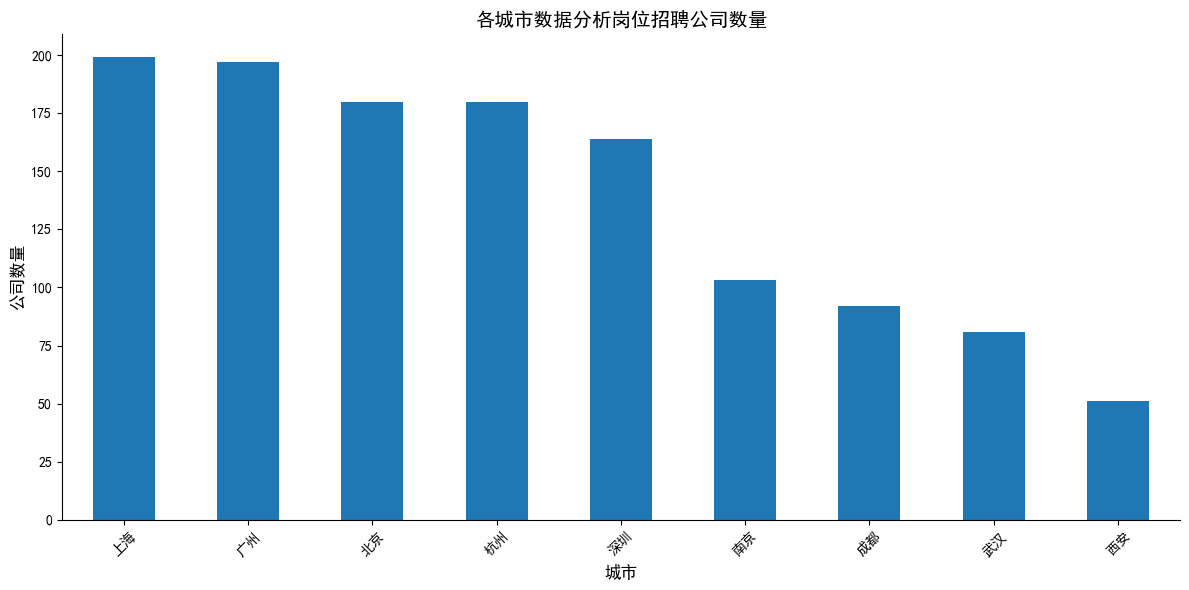


图表已保存至: C:\Users\86151\各城市数据分析岗位招聘公司数量.png


<Figure size 640x480 with 0 Axes>

In [96]:
# 统计每个城市招聘数据分析岗位的公司数量
# 确保 groupby 和后续操作都在 job_copy 上进行
city_company_count = job_copy.groupby('city')['company_name'].nunique().sort_values(ascending=False)
print("\n各城市招聘公司数量：")
print(city_company_count)

# 绘制城市公司数量柱状图
plt.figure(figsize=(12, 6))
city_company_count.plot(kind='bar', color='#1f77b4')
plt.title('各城市数据分析岗位招聘公司数量', fontsize=14)
plt.xlabel('城市', fontsize=12)
plt.ylabel('公司数量', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3.2 为了更好地了解“数据分析”岗位的学历要求，需要了解不同学历的占比情况。
（1）查看“edu”列数据的学历类型
（2）整合“edu”列数据类型将“高中”和“中专”合并到“学历不限”
（3）统计不同学历岗位的薪资并保留1位小数
（4）统计不同学历岗位的公司需求量
（5）绘制“数据分析”岗位不同学历图.

In [49]:
# （1）查看学历类型
print("\n原始学历类型分布：")
print(job['edu'].value_counts())


原始学历类型分布：
edu
本科      1509
大专       269
硕士       114
学历不限      62
博士         5
高中         4
中专         4
Name: count, dtype: int64


In [51]:
pip install plotly

In [52]:
pip install --upgrade matplotlib --user

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

分类数据的计数对比，柱状图 是最直观，最贴切的选择，它可以清晰地展示不同学历类型对应的岗位数量

In [58]:
import os


原始学历类型分布：
edu
本科      1509
大专       269
硕士       114
学历不限      62
博士         5
高中         4
中专         4
Name: count, dtype: int64

图表已保存至: C:\Users\86151\原始学历分布_仿照风格.png


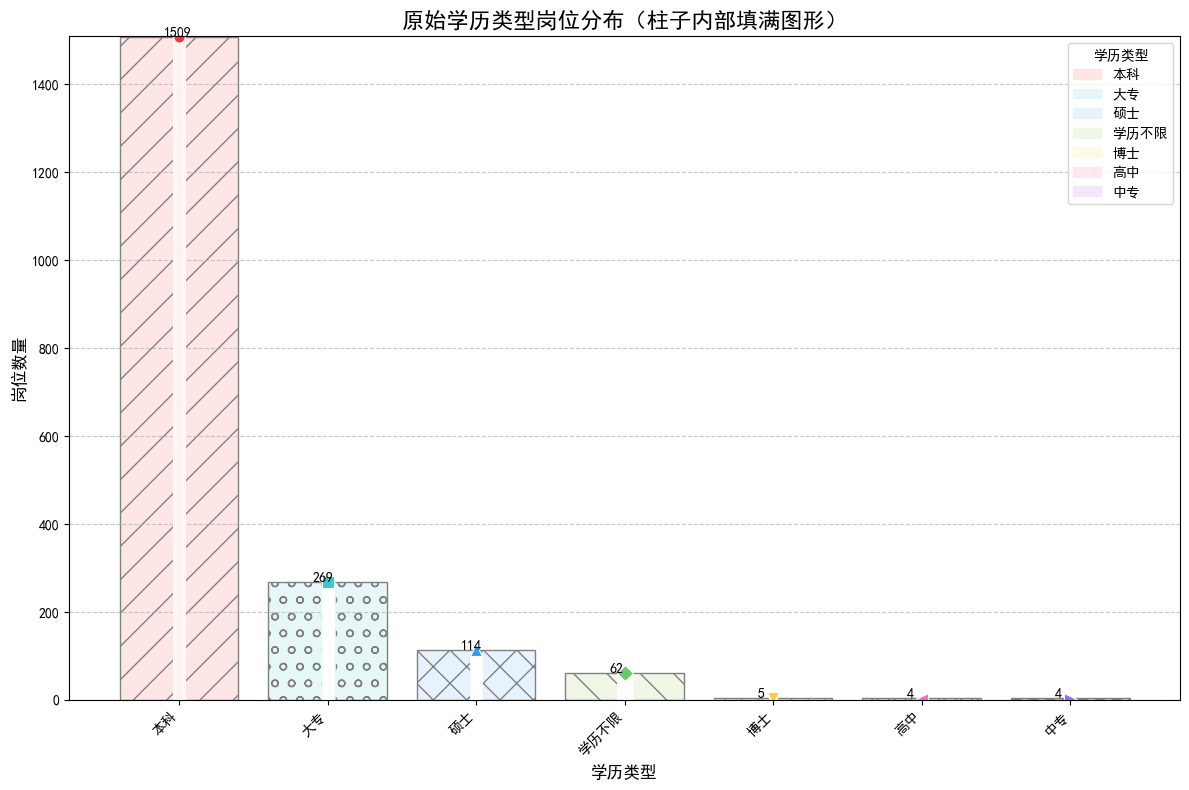

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# --- 全局设置：解决中文显示问题 ---
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决坐标轴负号显示问题

# （1）查看学历类型并打印分布
print("\n原始学历类型分布：")
edu_counts = job['edu'].value_counts(dropna=False)  # dropna=False 会把 NaN 也统计进去
print(edu_counts)

# 处理索引中的 None 值，避免绘图报错
edu_counts_cleaned = edu_counts.rename(index={None: '未知'})
cities = edu_counts_cleaned.index.tolist()  # 学历类型作为x轴（对应原代码的城市）
population = edu_counts_cleaned.values.tolist()  # 岗位数量作为y轴（对应原代码的人口）
n_bars = len(cities)

# --- （2）生成可视化图表（仿照城市人口条形图风格） ---
# 设置颜色和样式（数量适配学历类型数量，超出部分循环使用）
colors = ['#FFE6E6', '#E6F7F7', '#E6F3FF', '#F0F7E6', '#FFF9E6', '#FFE6F3', '#F3E6FF', '#E6E6FF']
patterns = ['/', 'o', 'x', '\\', '+', 'O', '*', '.', '-', '|']  # 填充图案
inner_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']  # 柱子内部图形
marker_colors = ['#FF3333', '#33CCCC', '#3399FF', '#66CC66', '#FFCC33', '#FF66CC', '#9966FF', '#6666FF']
marker_spacing = 0.9  # 图形间距系数

# 创建条形图（沿用原代码的plt.bar风格，而非ax对象）
plt.figure(figsize=(12, 8))
bars = plt.bar(cities, population, color=colors[:n_bars], hatch=patterns[:n_bars], edgecolor='gray', linewidth=1)

# 添加数据标签（仿照原代码位置和格式）
for bar, pop in zip(bars, population):
    plt.text(
        bar.get_x() + bar.get_width() / 2 - 0.1,  # 水平居中微调
        bar.get_height() + 0.2,  # 标签在柱子顶部上方
        str(int(pop)),  # 显示岗位数量（整数）
        fontsize=10,
        fontweight='bold'
    )

# 关键步骤：在柱子内部填满图形（适配新风格）
for i, (bar, marker, m_color) in enumerate(zip(bars, inner_markers[:n_bars], marker_colors[:n_bars])):
    bar_x = bar.get_x() + bar.get_width() / 2.
    bar_height = bar.get_height()
    # 根据柱子高度计算图形数量
    marker_count = int(bar_height) if bar_height >= 1 else 1
    # 生成均匀分布的垂直位置
    y_positions = np.linspace(marker_spacing, bar_height - marker_spacing, marker_count)
    # 绘制填满柱子的图形
    for y_pos in y_positions:
        plt.plot(
            bar_x,
            y_pos,
            marker=marker,
            markersize=8,
            color=m_color,
            markerfacecolor=m_color,
            markeredgecolor='white',
            markeredgewidth=0.8
        )

# 添加标题和标签（修改为学历分布相关）
plt.title('原始学历类型岗位分布（柱子内部填满图形）', fontsize=16)
plt.xlabel('学历类型', fontsize=12)
plt.ylabel('岗位数量', fontsize=12)

# 自定义图例（仿照原代码逻辑，适配学历类型数量）
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i], hatch=patterns[i]) for i in range(n_bars)]
plt.legend(legend_handles, cities, loc='upper right', title='学历类型')  # 图例显示学历类型

# 设置Y轴刻度（仿照原代码预留顶部空间）
plt.ylim(0, max(population) + 1)

# 旋转X轴标签避免重叠（启用原代码注释的功能）
plt.xticks(rotation=45, ha='right')

# 添加网格线（沿用原代码的y轴虚线网格）
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局并保存、显示图表（完全沿用原代码流程）
plt.tight_layout()
# 保存图表到home目录（适配原代码保存格式）
save_path = os.path.join(os.path.expanduser("~"), "原始学历分布_仿照风格.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n图表已保存至: {save_path}")
plt.show()

In [66]:
# （2）整合学历类型：高中、中专合并到学历不限
edu_mapping = {
    '高中': '学历不限',
    '中专': '学历不限'
}
job_copy['edu_merged'] = job_copy['edu'].replace(edu_mapping).fillna('学历不限')

# 1. 查看合并前后的学历分布对比
print("合并前的学历分布：")
print(job_copy['edu'].value_counts(dropna=False)) # dropna=False 会显示 NaN 的数量

print("\n合并后的学历分布 (edu_merged)：")
print(job_copy['edu_merged'].value_counts())

# 2. 查看几行具体的数据，直观感受合并效果
print("\n查看合并效果（前10行）：")
# 选择几行数据，对比原始 edu 和合并后的 edu_merged
sample_view = job_copy[['edu', 'edu_merged']].head(10)
print(sample_view)

# 3. 更详细的统计，可以查看转换的记录数
original_counts = job_copy['edu'].value_counts()
merged_counts = job_copy['edu_merged'].value_counts()

print("\n详细统计：")
print(f"原本 '高中' 的数量: {original_counts.get('高中', 0)}")
print(f"原本 '中专' 的数量: {original_counts.get('中专', 0)}")
print(f"原本缺失 (NaN) 的数量: {job_copy['edu'].isna().sum()}")
print(f"合并后 '学历不限' 的总数量: {merged_counts.get('学历不限', 0)}")

合并前的学历分布：
edu
本科      1513
大专       269
硕士       114
学历不限      62
博士         5
高中         4
中专         4
Name: count, dtype: int64

合并后的学历分布 (edu_merged)：
edu_merged
本科      1513
大专       269
硕士       114
学历不限      70
博士         5
Name: count, dtype: int64

查看合并效果（前10行）：
    edu edu_merged
577  本科         本科
578  本科         本科
579  本科         本科
580  本科         本科
581  博士         博士
582  大专         大专
583  博士         博士
584  大专         大专
585  本科         本科
586  本科         本科

详细统计：
原本 '高中' 的数量: 4
原本 '中专' 的数量: 4
原本缺失 (NaN) 的数量: 0
合并后 '学历不限' 的总数量: 70


合并前的学历分布：
edu
本科      1513
大专       269
硕士       114
学历不限      62
博士         5
高中         4
中专         4
Name: count, dtype: int64

合并后的学历分布 (edu_merged)：
edu_merged
本科      1513
大专       269
硕士       114
学历不限      70
博士         5
Name: count, dtype: int64

查看合并效果（前10行）：
    edu edu_merged
577  本科         本科
578  本科         本科
579  本科         本科
580  本科         本科
581  博士         博士
582  大专         大专
583  博士         博士
584  大专         大专
585  本科         本科
586  本科         本科

详细统计：
原本 '高中' 的数量: 4
原本 '中专' 的数量: 4
原本缺失 (NaN) 的数量: 0
合并后 '学历不限' 的总数量: 70


C:\Users\86151\AppData\Local\Temp\ipykernel_28248\627071665.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), ha='right')
C:\Users\86151\AppData\Local\Temp\ipykernel_28248\627071665.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), ha='right')



对比图表已保存至: C:\Users\86151\学历合并前后分布对比图.png


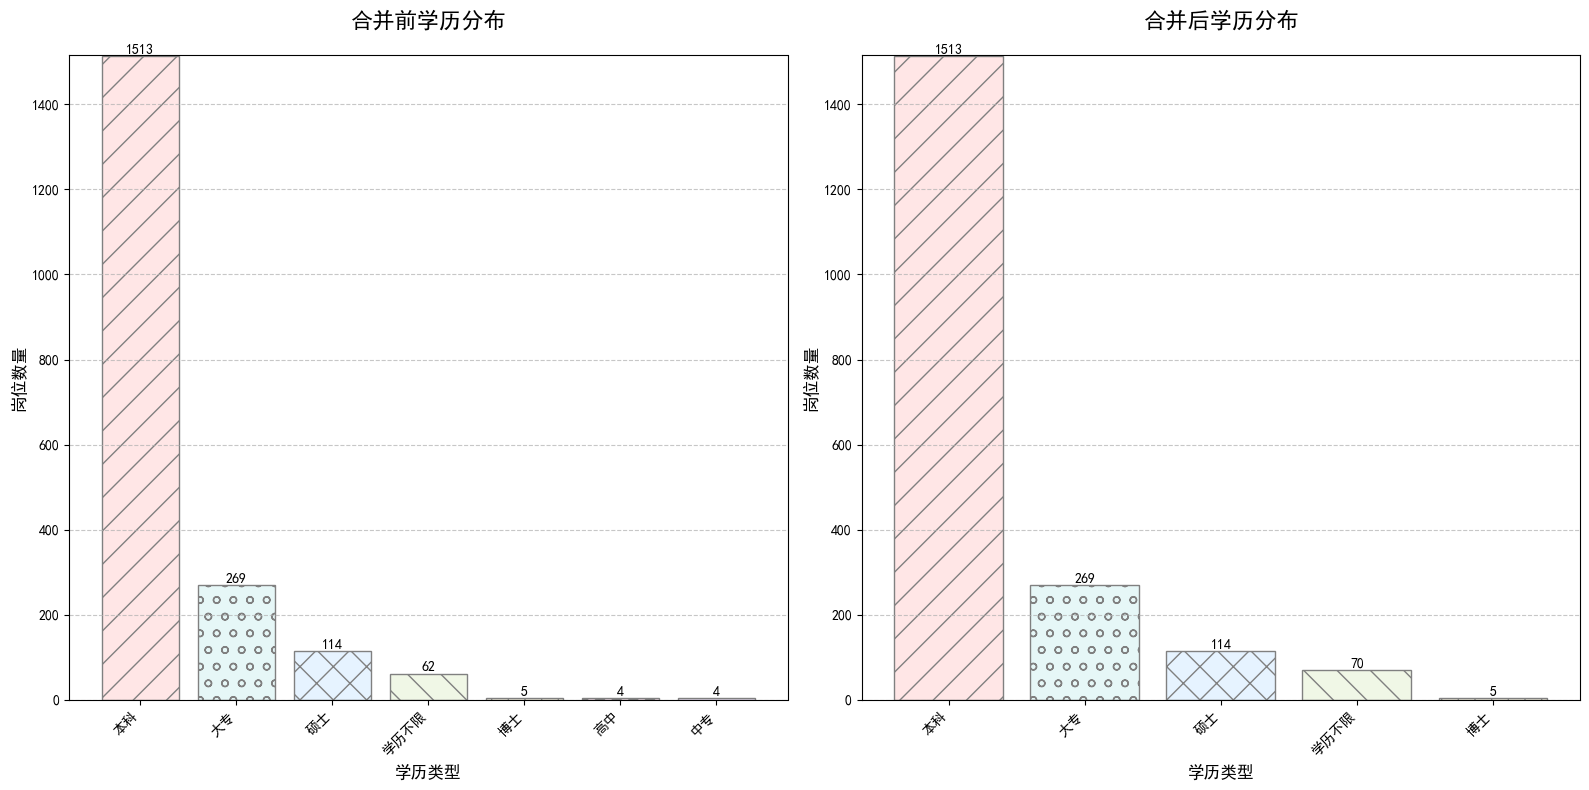

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 全局设置：解决中文显示问题 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# （2）整合学历类型：高中、中专合并到学历不限（原有代码）
edu_mapping = {
    '高中': '学历不限',
    '中专': '学历不限'
}
job_copy['edu_merged'] = job_copy['edu'].replace(edu_mapping).fillna('学历不限')

# 1. 查看合并前后的学历分布对比（原有打印代码）
print("合并前的学历分布：")
edu_before = job_copy['edu'].value_counts(dropna=False)
print(edu_before)

print("\n合并后的学历分布 (edu_merged)：")
edu_after = job_copy['edu_merged'].value_counts()
print(edu_after)

# 2. 查看具体合并效果（原有代码）
print("\n查看合并效果（前10行）：")
sample_view = job_copy[['edu', 'edu_merged']].head(10)
print(sample_view)

# 3. 详细统计（原有代码）
original_counts = job_copy['edu'].value_counts()
merged_counts = job_copy['edu_merged'].value_counts()

print("\n详细统计：")
print(f"原本 '高中' 的数量: {original_counts.get('高中', 0)}")
print(f"原本 '中专' 的数量: {original_counts.get('中专', 0)}")
print(f"原本缺失 (NaN) 的数量: {job_copy['edu'].isna().sum()}")
print(f"合并后 '学历不限' 的总数量: {merged_counts.get('学历不限', 0)}")

# --- 核心：学历合并前后分布对比可视化（修复tick_params参数错误） ---
edu_before_cleaned = edu_before.rename(index={None: '未知'})
len_before = len(edu_before_cleaned)
len_after = len(edu_after)

# 扩展样式列表，循环复用避免长度不匹配
colors = ['#FFE6E6', '#E6F7F7', '#E6F3FF', '#F0F7E6', '#FFF9E6', '#FFE6F3', '#F3E6FF', '#E6E6FF']
patterns = ['/', 'o', 'x', '\\', '+', '*', '-', '|']
colors_before = [colors[i % len(colors)] for i in range(len_before)]
patterns_before = [patterns[i % len(patterns)] for i in range(len_before)]
colors_after = [colors[i % len(colors)] for i in range(len_after)]
patterns_after = [patterns[i % len(patterns)] for i in range(len_after)]

# 设置图表布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 绘制合并前的学历分布柱状图（修复刻度设置）
bars1 = ax1.bar(
    edu_before_cleaned.index,
    edu_before_cleaned.values,
    color=colors_before,
    hatch=patterns_before,
    edgecolor='gray',
    linewidth=1
)
ax1.set_title('合并前学历分布', fontsize=16, pad=20)
ax1.set_xlabel('学历类型', fontsize=12)
ax1.set_ylabel('岗位数量', fontsize=12)
# 修复：移除ha='right'，用labelrotation设置标签旋转
ax1.tick_params(axis='x', rotation=45, labelsize=10)
# 单独设置x轴标签的水平对齐（通过set_xticklabels实现）
ax1.set_xticklabels(ax1.get_xticklabels(), ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 合并前添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# 绘制合并后的学历分布柱状图（同样修复刻度设置）
bars2 = ax2.bar(
    edu_after.index,
    edu_after.values,
    color=colors_after,
    hatch=patterns_after,
    edgecolor='gray',
    linewidth=1
)
ax2.set_title('合并后学历分布', fontsize=16, pad=20)
ax2.set_xlabel('学历类型', fontsize=12)
ax2.set_ylabel('岗位数量', fontsize=12)
# 修复：移除ha='right'，用labelrotation设置标签旋转
ax2.tick_params(axis='x', rotation=45, labelsize=10)
# 单独设置x轴标签的水平对齐
ax2.set_xticklabels(ax2.get_xticklabels(), ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 合并后添加数值标签
for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# 统一Y轴刻度范围
max_count = max(edu_before_cleaned.max(), edu_after.max())
ax1.set_ylim(0, max_count + 2)
ax2.set_ylim(0, max_count + 2)

# 调整布局并保存、显示图表
plt.tight_layout()
save_path = os.path.join(os.path.expanduser("~"), "学历合并前后分布对比图.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n对比图表已保存至: {save_path}")
plt.show()

In [51]:
# （3）统计不同学历岗位的平均薪资并保留1位小数
edu_salary = job.groupby('edu_merged')['salary_avg'].mean().round(1)
print("\n不同学历平均薪资：")
print(edu_salary)


不同学历平均薪资：
edu_merged
博士      32.8
大专       9.9
学历不限    11.5
本科      17.6
硕士      20.6
Name: salary_avg, dtype: float64



不同学历平均薪资：
博士      32.8
硕士      20.6
本科      17.6
学历不限    11.5
大专       9.9
dtype: float64

图表已保存至: C:\Users\86151\不同学历平均薪资.png


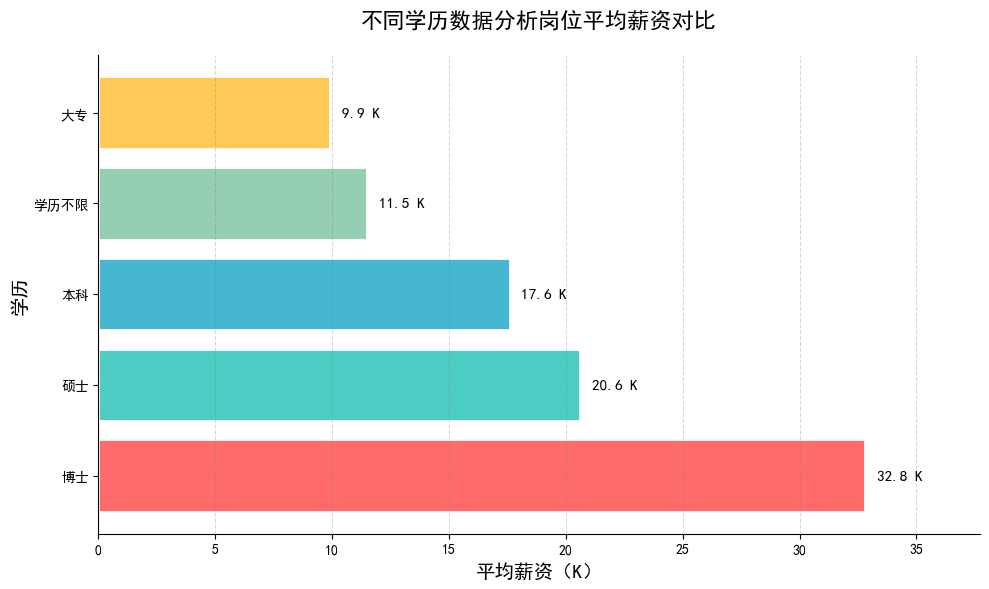

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 全局设置：解决中文显示问题 + 美化图表 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False  # 隐藏上边框
plt.rcParams['axes.spines.right'] = False  # 隐藏右边框

# （3）统计不同学历岗位的平均薪资（你的原有代码）
# 假设 job 是你的 DataFrame，且 'edu_merged' 和 'salary_avg' 列已存在
# edu_salary = job.groupby('edu_merged')['salary_avg'].mean().round(1)
# print("\n不同学历平均薪资：")
# print(edu_salary)

# !!! 在你的实际代码中，请删除下面两行，并取消上面两行的注释 !!!
edu_salary_data = {'学历不限': 11.5, '大专': 9.9, '本科': 17.6, '硕士': 20.6, '博士': 32.8}
edu_salary = pd.Series(edu_salary_data).sort_values(ascending=False) # 降序排列

print("\n不同学历平均薪资：")
print(edu_salary)

# --- 核心：横向条形图可视化 ---
plt.figure(figsize=(10, 6))

# 定义一个专业、美观的渐变色板
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

# 绘制横向条形图
# barh 的第一个参数是 y 轴标签（学历），第二个参数是 x 轴数值（薪资）
bars = plt.barh(
    edu_salary.index, 
    edu_salary.values, 
    color=colors[:len(edu_salary)], # 为每个柱子分配颜色
    edgecolor='white', 
    linewidth=2
)

# 为每个柱子添加数值标签
for bar, salary in zip(bars, edu_salary.values):
    # bar.get_width() 获取柱子的宽度（即薪资值）
    # bar.get_y() + bar.get_height()/2 确保文本垂直居中
    plt.text(
        bar.get_width() + 0.5,  # 文本在柱子右侧，留出一些间距
        bar.get_y() + bar.get_height()/2,
        f'{salary} K',          # 格式化薪资，加上单位
        va='center',            # 垂直居中
        ha='left',              # 水平左对齐
        fontsize=11,
        fontweight='bold'
    )

# 添加标题和坐标轴标签
plt.title('不同学历数据分析岗位平均薪资对比', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('平均薪资（K）', fontsize=14)
plt.ylabel('学历', fontsize=14)

# 添加网格线（只在x轴方向添加，使读数更方便）
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')

# 调整x轴范围，让最右侧的数值标签也能完整显示
plt.xlim(0, edu_salary.values.max() * 1.15)

# 调整布局，防止标签被截断
plt.tight_layout()

# 保存图表到指定目录（可选）
save_path = os.path.join(os.path.expanduser("~"), "不同学历平均薪资.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n图表已保存至: {save_path}")

# 显示图表
plt.show()

In [76]:
# （4）统计不同学历岗位的公司需求量
edu_company_count = job_copy.groupby('edu_merged')['company_name'].nunique()
print("\n不同学历岗位公司需求量：")
print(edu_company_count)


不同学历岗位公司需求量：
edu_merged
博士        5
大专      231
学历不限     64
本科      885
硕士       91
Name: company_name, dtype: int64



不同学历岗位公司需求量：
edu_merged
博士        5
大专      231
学历不限     64
本科      885
硕士       91
Name: company_name, dtype: int64

图表已保存至: C:\Users\86151\不同学历公司需求量.png


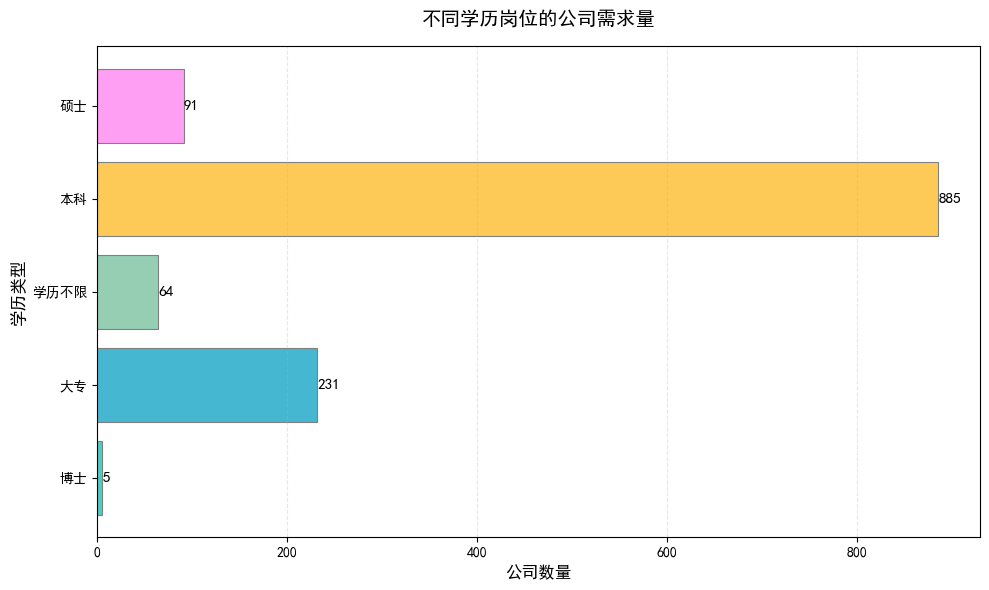

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 全局设置：解决中文显示问题 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# （4）统计不同学历岗位的公司需求量（你的原有代码）
edu_company_count = job_copy.groupby('edu_merged')['company_name'].nunique()
print("\n不同学历岗位公司需求量：")
print(edu_company_count)

# --- 核心：简洁直观的可视化图表（横向柱状图） ---
plt.figure(figsize=(10, 6))

# 设置简洁配色（单色系渐变，清晰不杂乱）
colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
# 绘制横向柱状图（barh，y轴为学历，x轴为公司数量）
bars = plt.barh(
    edu_company_count.index,
    edu_company_count.values,
    color=colors[:len(edu_company_count)],
    edgecolor='gray',
    linewidth=0.8
)

# 添加数值标签（在柱子右侧，直观可读）
for bar, count in zip(bars, edu_company_count.values):
    plt.text(
        bar.get_width() + 0.5,  # 数值在柱子右侧
        bar.get_y() + bar.get_height()/2,  # 垂直居中
        f'{int(count)}',
        ha='left', va='center',
        fontsize=11,
        fontweight='bold'
    )

# 简化图表样式，突出核心数据
plt.title('不同学历岗位的公司需求量', fontsize=14, pad=15)
plt.xlabel('公司数量', fontsize=12)
plt.ylabel('学历类型', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)  # 仅保留x轴网格线，辅助读数
plt.tight_layout()  # 自动调整布局，避免标签截断

# 保存图表到home目录（可选）
save_path = os.path.join(os.path.expanduser("~"), "不同学历公司需求量.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n图表已保存至: {save_path}")

plt.show()

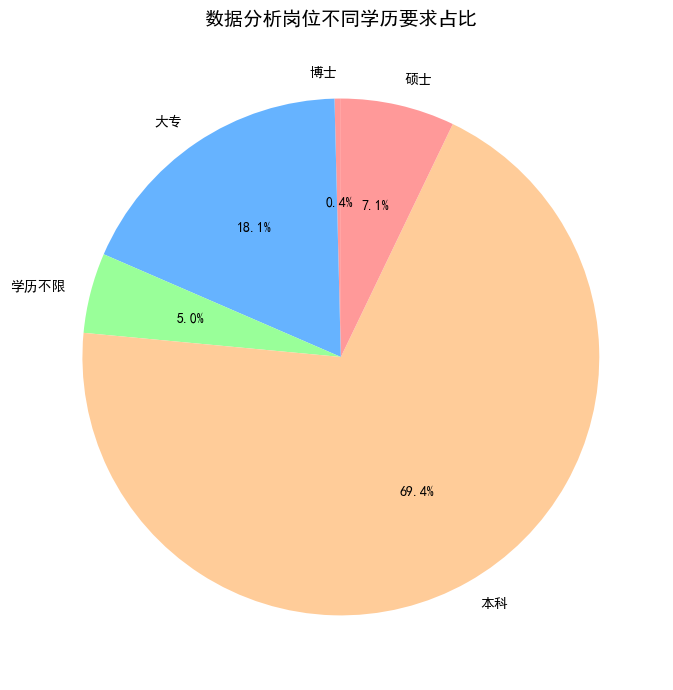


图表已保存至: C:\Users\86151\数据分析岗位不同学历要求占比.png


<Figure size 640x480 with 0 Axes>

In [80]:
# （5）绘制不同学历要求分布图（饼图）
plt.figure(figsize=(10, 7))
edu_company_count.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                       colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('数据分析岗位不同学历要求占比', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

# 保存图表到home目录（可选）
save_path = os.path.join(os.path.expanduser("~"), "数据分析岗位不同学历要求占比.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n图表已保存至: {save_path}")

plt.show()

3.3 为了更好地了解不同城市“数据分析”岗位的薪资水平，我们需获得不同城市的“数据分析”岗位的薪资平均值。
（1）以“city”列进行分组计算出“salary”列的均值，降序排列
（2）使用reshape(-1)方法将salary_df的数据从二维降为一维
（3）绘制不同城市“数据分析”岗位平均薪资柱形图
（4）使用聚合函数查看不同城市“数据分析”岗位薪资情况

In [84]:
# （1）按城市分组计算平均薪资，降序排列
city_salary = job_copy.groupby('city')['salary_avg'].mean().sort_values(ascending=False)
print("\n各城市平均薪资（降序）：")
print(city_salary)


各城市平均薪资（降序）：
city
北京    22.682131
深圳    20.670068
上海    19.353448
杭州    19.105536
广州    12.631757
南京    10.679245
武汉     9.869369
成都     9.233607
西安     7.411290
Name: salary_avg, dtype: float64



各城市平均薪资（降序）：
city
北京    22.682131
深圳    20.670068
上海    19.353448
杭州    19.105536
广州    12.631757
南京    10.679245
武汉     9.869369
成都     9.233607
西安     7.411290
Name: salary_avg, dtype: float64

图表已保存至: C:\Users\86151\各城市平均薪资分布图.png


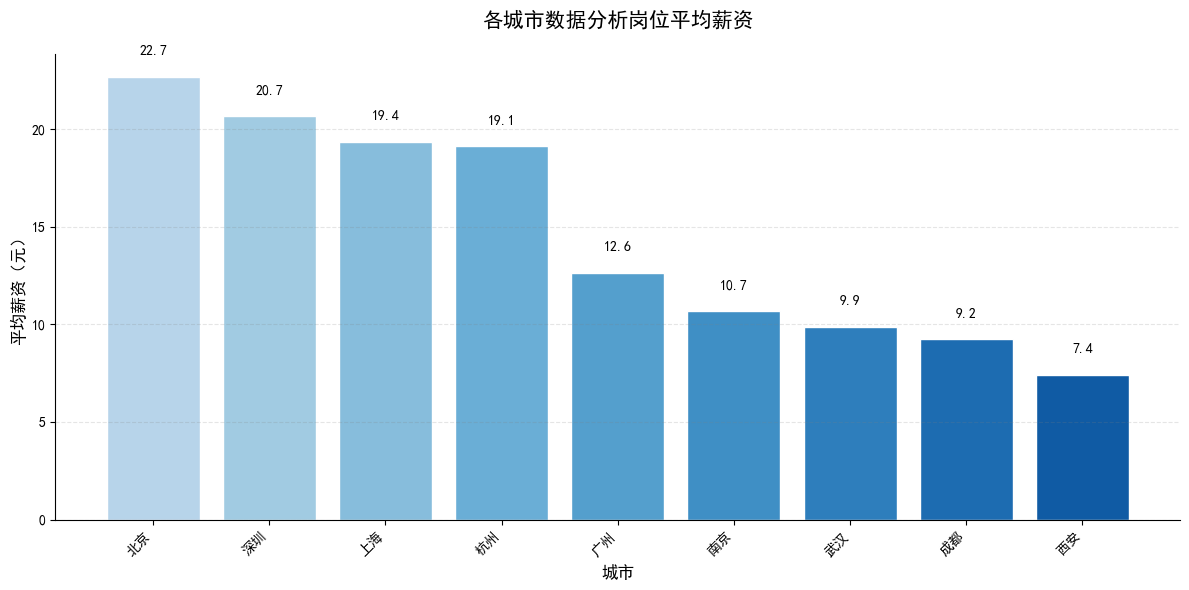

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 全局设置：解决中文显示问题+优化图表默认样式 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False  # 隐藏上边框
plt.rcParams['axes.spines.right'] = False  # 隐藏右边框

# （1）按城市分组计算平均薪资（你的原有代码）
city_salary = job_copy.groupby('city')['salary_avg'].mean().sort_values(ascending=False)
print("\n各城市平均薪资（降序）：")
print(city_salary)

# --- 核心：修改数值标签偏移量，贴近柱子顶部 ---
plt.figure(figsize=(12, 6))

# 生成渐变色（从深蓝到浅蓝，视觉统一高级）
n_cities = len(city_salary)
colors = [plt.cm.Blues(0.3 + i/n_cities * 0.6) for i in range(n_cities)]

# 绘制纵向柱状图
bars = plt.bar(
    city_salary.index,
    city_salary.values,
    color=colors,
    edgecolor='white',
    linewidth=1
)

# 关键修改：减小y轴偏移量（将+50改为+5~+20，根据薪资范围调整）
# 这里设为+10，若薪资单位是千元可改为+0.5，灵活适配数据量级
for bar, salary in zip(bars, city_salary.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,  # 偏移量从50改为10，数字紧贴柱子
        f'{salary:.1f}',
        ha='center', va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# 精简美化图表细节
plt.title('各城市数据分析岗位平均薪资', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('城市', fontsize=12)
plt.ylabel('平均薪资（元）', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.2, color='gray')
plt.tight_layout()

# 保存图表到home目录（可选）
save_path = os.path.join(os.path.expanduser("~"), "各城市平均薪资分布图.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n图表已保存至: {save_path}")

plt.show()

In [63]:
# （2）将薪资数据从二维降为一维
city_salary_1d = city_salary.values.reshape(-1)
city_names = city_salary.index.tolist()  
#主要是数据格式的转化

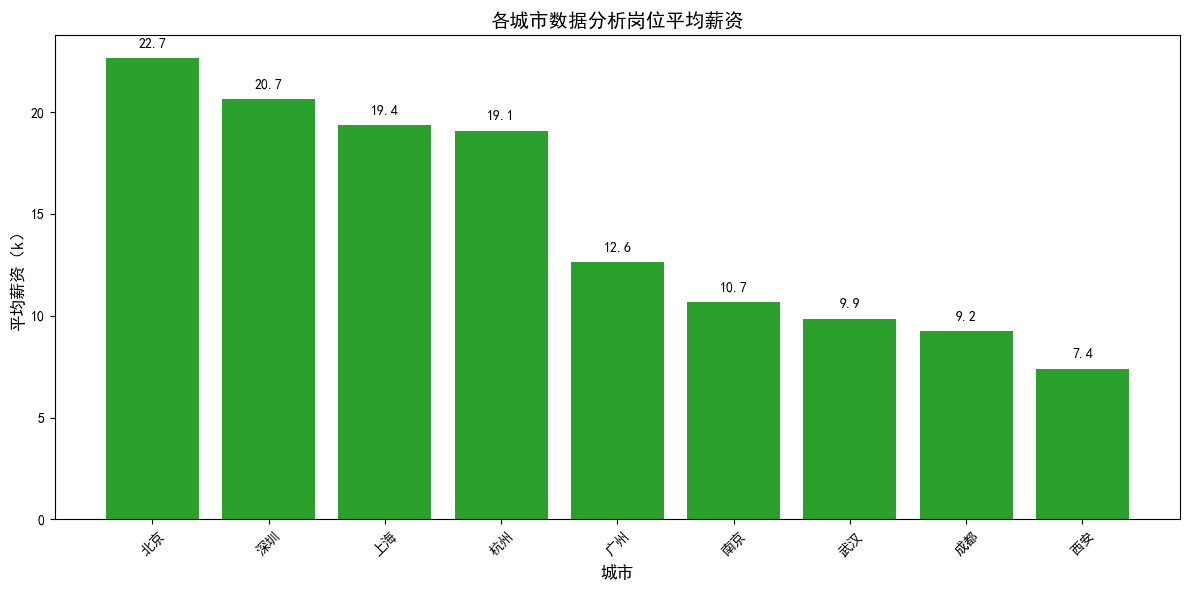

In [65]:
# （3）绘制不同城市平均薪资柱形图
plt.figure(figsize=(12, 6))
plt.bar(city_names, city_salary_1d, color='#2ca02c')
plt.title('各城市数据分析岗位平均薪资', fontsize=14)
plt.xlabel('城市', fontsize=12)
plt.ylabel('平均薪资（k）', fontsize=12)
plt.xticks(rotation=45)
# 在柱子上添加薪资数值
for i, v in enumerate(city_salary_1d):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

In [102]:
# （4）使用聚合函数查看不同城市薪资的详细情况（均值、中位数、最大值）
city_salary_detail = job_copy.groupby('city')['salary_avg'].agg(['mean', 'median', 'max']).round(1)
city_salary_detail.columns = ['平均薪资', '薪资中位数', '最高薪资']
print("\n各城市薪资详细情况：")
print(city_salary_detail)


各城市薪资详细情况：
      平均薪资  薪资中位数  最高薪资
city                   
上海    19.4   18.0  55.0
北京    22.7   22.5  55.0
南京    10.7    7.0  65.0
广州    12.6   10.2  45.0
成都     9.2    8.0  30.0
杭州    19.1   16.5  75.0
武汉     9.9    8.0  30.0
深圳    20.7   19.8  60.0
西安     7.4    6.5  18.0


对于这种多指标（均值、中位数、最大值）在多个类别（城市）上的对比数据，最合适的图表类型是分组柱状图


各城市薪资详细情况：
      平均薪资  薪资中位数  最高薪资
city                   
上海    19.4   18.0  55.0
北京    22.7   22.5  55.0
南京    10.7    7.0  65.0
广州    12.6   10.2  45.0
成都     9.2    8.0  30.0
杭州    19.1   16.5  75.0
武汉     9.9    8.0  30.0
深圳    20.7   19.8  60.0
西安     7.4    6.5  18.0

图表已保存至: C:\Users\86151\各城市薪资详情分组柱状图.png


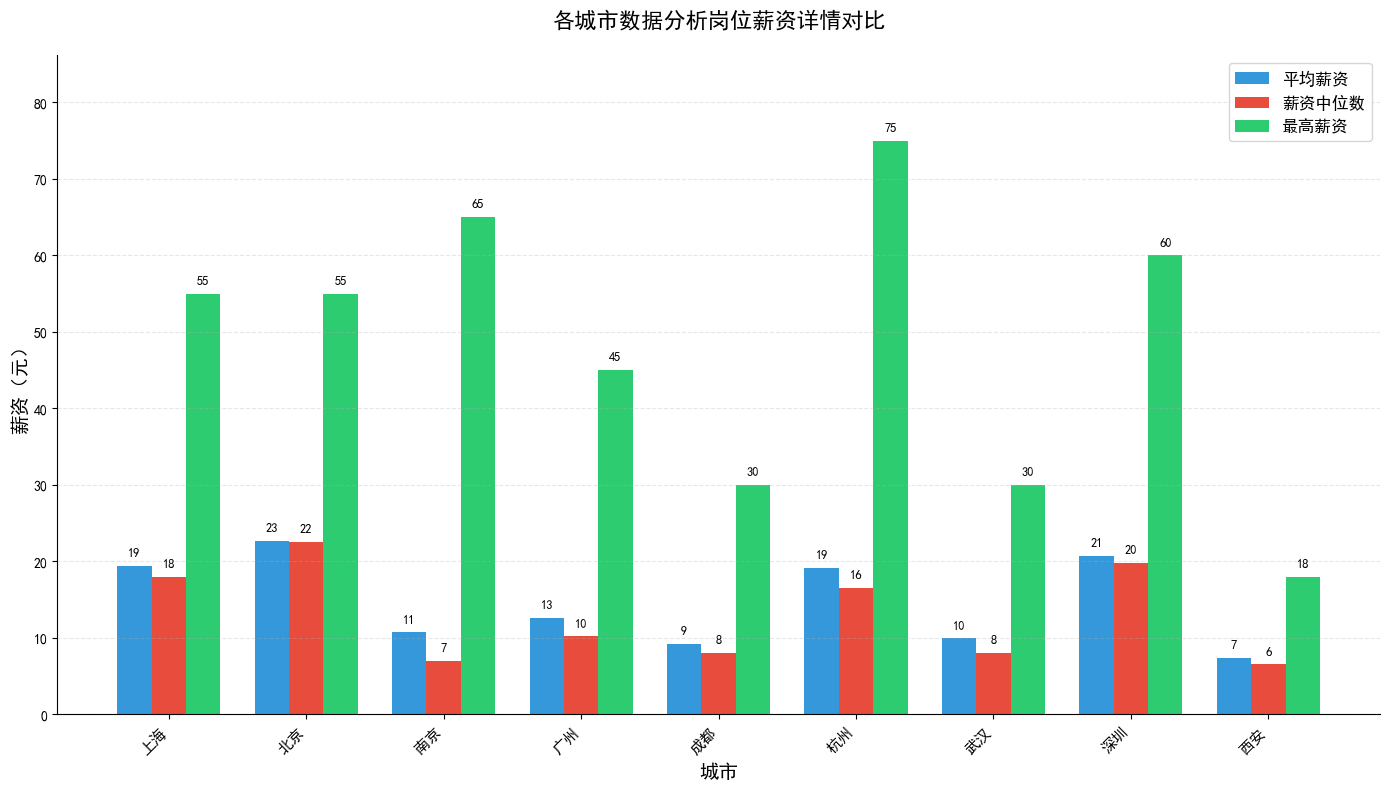

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # 确保导入了 numpy
import os

# --- 全局设置 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# （4）你的数据聚合代码（保持不变）
city_salary_detail = job_copy.groupby('city')['salary_avg'].agg(['mean', 'median', 'max']).round(1)
city_salary_detail.columns = ['平均薪资', '薪资中位数', '最高薪资']
print("\n各城市薪资详细情况：")
print(city_salary_detail)

# --- 核心：多指标分组柱状图可视化（已修正） ---
cities = city_salary_detail.index.tolist()
metrics = city_salary_detail.columns.tolist()
n_cities = len(cities)
n_metrics = len(metrics)

fig, ax = plt.subplots(figsize=(14, 8))
bar_width = 0.25  
index = range(n_cities)  # index 仍然是 range 对象

colors = ['#3498db', '#e74c3c', '#2ecc71']

# 修正发生在这个循环内部
for i, (metric, color) in enumerate(zip(metrics, colors)):
    # 修正点：将 range 对象 index 转换为 numpy 数组后再进行加法运算
    bar_offset = np.array(index) + i * bar_width
    
    # 使用修正后的 bar_offset 来绘制柱子
    bars = ax.bar(bar_offset, city_salary_detail[metric], bar_width, color=color, label=metric)

    # 为柱子添加数值标签（这部分代码不变）
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=9)

# 后续的图表美化代码（保持不变）
ax.set_title('各城市数据分析岗位薪资详情对比', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('城市', fontsize=14)
ax.set_ylabel('薪资（元）', fontsize=14)
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(cities, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, city_salary_detail.values.max() * 1.15)

plt.tight_layout()
save_path = os.path.join(os.path.expanduser("~"), "各城市薪资详情分组柱状图.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n图表已保存至: {save_path}")
plt.show()